# Multi-Asset Allocation

## Data

This problem uses `weekly` data from `data/asset_class_etf_data.xlsx`.
* tab `excess returns`: weekly returns net of cash (`SHV`)
* tab `descriptions`: what each ticker holds

One fund per asset class, built across the course:
* equities: `SPY`, `VEA`
* bonds and credit: `IEF`, `HYG`
* commodities: `GLD`, `USO`
* crypto: `BTC`

`BTC` is the spot bitcoin series. It became investable in ETF form in late 2021 (`BITO`, futures-based) and via spot ETFs (`IBIT`, `FBTC`) in January 2024. The out-of-sample window below starts in 2022: the ETF era.

Annualize weekly stats with a factor of `52`.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIRS = ['..', '../data', 'data', 'FINM 25000', '../FINM 25000', '.']


def find_file(name):
    for d in DATA_DIRS:
        p = Path(d) / name
        if p.exists():
            return p
    raise FileNotFoundError(name)


FILE = find_file('asset_class_etf_data.xlsx')
ANN = 52  # weeks per year

rets = pd.read_excel(FILE, sheet_name='excess returns', index_col=0, parse_dates=True)
ASSETS = list(rets.columns)   # SPY VEA IEF HYG GLD USO BTC (excess of cash)
print(rets.shape, rets.index.min().date(), '->', rets.index.max().date())
rets.head()

(494, 7) 2017-01-13 -> 2026-06-26


,SPY,VEA,IEF,HYG,GLD,USO,BTC
Date,,,,,,,
2017-01-13,-0.000886,0.009979,0.002673,0.000850,0.021832,-0.023298,-0.086877
2017-01-20,-0.001456,-0.004326,-0.005499,-0.001465,0.007264,-0.001843,0.086127
2017-01-27,0.009926,0.010723,-0.000863,0.004793,-0.013469,0.000969,0.027714
2017-02-03,0.001797,0.005705,0.001041,-0.001303,0.023443,0.012462,0.119953
2017-02-10,0.009281,0.000603,0.003826,0.000390,0.012477,-0.003647,-0.040220


# 1 The Asset Menu

## 1.1

For each asset, calculate over the full sample the annualized
* mean
* volatility
* Sharpe ratio

## 1.2

Report the correlation matrix.

Which asset offers the most diversification against `SPY`?

## 1.3

Report each asset's empirical VaR (.05) of weekly returns.

Which assets carry the most tail risk?

In [6]:
# 1.1  annualized mean, volatility, Sharpe (excess returns -> Sharpe = mean / vol)
summary = pd.DataFrame({'mean': rets.mean() * ANN, 'vol': rets.std() * np.sqrt(ANN)})
summary['sharpe'] = summary['mean'] / summary['vol']
summary.round(4)

,mean,vol,sharpe
SPY,0.1382,0.1745,0.7918
VEA,0.0820,0.1731,0.4737
IEF,-0.0086,0.0633,-0.1357
HYG,-0.0047,0.0961,-0.0489
GLD,0.1386,0.1513,0.9161
USO,0.0992,0.4103,0.2417
BTC,0.6759,0.6877,0.9829


BTC has the highest mean (68%) but also the highest volatility (69%), for a Sharpe of about **0.98**. GLD is the best risk-adjusted of the traditional assets (**0.92**), then SPY (**0.79**). Because these are returns *net of cash*, the bond and credit names (IEF, HYG) are roughly flat to slightly negative in excess terms over 2017–2026 (rates rose), and USO is high volatility (41%) for a weak 0.24 Sharpe.

In [9]:
# 1.2  correlation matrix; diversification against SPY = lowest correlation with SPY
corr = rets.corr()
print(corr.round(2).to_string())
print('\nCorrelation with SPY, low to high:')
print(corr['SPY'].drop('SPY').sort_values().round(3).to_string())

      SPY   VEA   IEF   HYG   GLD   USO   BTC
SPY  1.00  0.85 -0.02  0.77  0.21  0.23  0.19
VEA  0.85  1.00  0.04  0.73  0.32  0.18  0.21
IEF -0.02  0.04  1.00  0.15  0.29 -0.18 -0.00
HYG  0.77  0.73  0.15  1.00  0.23  0.18  0.11
GLD  0.21  0.32  0.29  0.23  1.00  0.08  0.12
USO  0.23  0.18 -0.18  0.18  0.08  1.00  0.07
BTC  0.19  0.21 -0.00  0.11  0.12  0.07  1.00

Correlation with SPY, low to high:
IEF   -0.017
BTC    0.192
GLD    0.206
USO    0.228
HYG    0.767
VEA    0.847


**IEF (7–10y Treasuries) offers the most diversification against SPY** — its correlation is about **-0.02**, essentially uncorrelated (even slightly negative). GLD, BTC, and USO are also low (~0.19–0.23). By contrast HYG (0.77) and VEA (0.85) are highly correlated with SPY — they are mostly equity beta, so they add little diversification.

In [12]:
# 1.3  empirical 5% VaR of weekly returns (5th percentile)
var05 = rets.quantile(0.05).sort_values()
var05.to_frame('VaR(.05) weekly').round(4)

,VaR(.05) weekly
BTC,-0.1373
USO,-0.0814
VEA,-0.0344
SPY,-0.0322
GLD,-0.0308
HYG,-0.0152
IEF,-0.0148


**BTC carries by far the most tail risk** — a weekly 5% VaR of about **-13.7%** — followed by **USO at -8.1%**. The equity and gold names cluster around -3%, and IEF / HYG are smallest (~-1.5%). So crypto and oil dominate the left tail.

***

# 2 Simple Rules

Two portfolios that require no optimization:
* equally-weighted across the 7 assets, rebalanced weekly
* `60/40`: 60% `SPY`, 40% `IEF`, rebalanced weekly

## 2.1

For each, report the annualized mean, volatility, and Sharpe over the full sample.

## 2.2

Report each portfolio's empirical VaR (.05). Compare to the individual assets in 1.3.

In [18]:
# 2.1  two no-optimization rules, rebalanced weekly
ew = rets.mean(axis=1)                         # equal weight, 1/7 each
p6040 = 0.60 * rets['SPY'] + 0.40 * rets['IEF']


def perf(x):
    m = x.mean() * ANN
    v = x.std() * np.sqrt(ANN)
    return pd.Series({'mean': m, 'vol': v, 'sharpe': m / v})


rules = pd.DataFrame({'equal-weight': perf(ew), '60/40': perf(p6040)}).T
rules.round(4)

,mean,vol,sharpe
equal-weight,0.1601,0.1516,1.0561
60/40,0.0795,0.1073,0.7406


The **equal-weight** portfolio earns mean 16.0%, vol 15.2%, Sharpe **1.06** — a higher Sharpe than *any single asset* (best single was BTC at 0.98), purely from diversification across low-correlation sleeves. **60/40** (SPY/IEF) earns mean 8.0%, vol 10.7%, Sharpe **0.74**: lower return, but a classic balanced mix. Equal-weight wins here largely because it includes the high-Sharpe, low-correlation names (BTC, GLD) that 60/40 leaves out.

In [21]:
# 2.2  empirical 5% VaR of the two rules, vs the individual assets from 1.3
port_var = pd.Series({'equal-weight': ew.quantile(0.05), '60/40': p6040.quantile(0.05)})
port_var.to_frame('VaR(.05) weekly').round(4)

,VaR(.05) weekly
equal-weight,-0.0292
60/40,-0.0213


Equal-weight VaR(.05) is about **-2.9%** and 60/40 about **-2.1%** — both far smaller than the riskiest single assets (BTC -13.7%, USO -8.1%), and below most individual names. That is striking for equal-weight, which holds a 1/7 slice of BTC yet still has only a ~2.9% weekly tail: the assets do not all crash in the same week, so blending them cuts the tail. 60/40's tail is close to its bond-heavy IEF/HYG level. This is exactly the diversification benefit the simple rules are meant to capture.

***

# 3 Mean-Variance Optimization

In [26]:
from pathlib import Path
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount('/content/drive')
ROOT = Path('/content/drive/MyDrive/FINM 25000 Group B')
FILE = ROOT / 'data' / 'asset_class_etf_data.xlsx'

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

ANN = 52

rets = pd.read_excel(FILE, sheet_name='excess returns', index_col=0, parse_dates=True)
ASSETS = list(rets.columns)
descriptions = pd.read_excel(FILE, sheet_name='descriptions', index_col=0)

print(rets.shape, rets.index.min().date(), '->', rets.index.max().date())
rets.head()

ModuleNotFoundError: No module named 'google.colab'

Estimate using data **through 2021 only**. (2022 onward is held out for Section 5.)

Exclude `BTC` for this section: the menu is the 6 traditional assets.

## 3.1

Calculate the tangency portfolio weights.

$$\wtan = \frac{\Sigma^{-1}\mu}{\mathbf{1}'\Sigma^{-1}\mu}$$

## 3.2

Do the weights look like a portfolio you could hold? Note any extreme or short positions.

## 3.3

Report the in-sample (through 2021) annualized mean, volatility, and Sharpe of the tangency portfolio, alongside the equal-weight and `60/40` portfolios over the same window.

In [29]:
#3.1
ins = rets.loc[:'2021']
trad = ins.drop(columns='BTC')

def tangency(r):
    w = np.linalg.solve(r.cov(), r.mean())
    return pd.Series(w / w.sum(), index=r.columns)

wtan6 = tangency(trad)
wtan6.to_frame('tangency weight').round(4)

# 3.2
pd.Series({'long': wtan6[wtan6 > 0].sum(), 'short': wtan6[wtan6 < 0].sum(),
           'gross': wtan6.abs().sum(), 'net': wtan6.sum()}).round(2)


long     3.43
short   -2.43
gross    5.87
net      1.00
dtype: float64

No, these weights are not a portfolio you could realistically hold. The optimizer wants 197% in SPY, 106% in IEF, and 40% in GLD, funded by shorting 156% of HYG and 83% of VEA (plus a small USO short). That is about 3.4x long and 2.4x short, so roughly 5.9x gross exposure for one dollar of capital. The shorts are not a view that VEA and HYG will fall. Both are highly correlated with SPY (0.85 and 0.77) but had much lower in-sample Sharpe, so the optimizer shorts them as hedges to lever up more SPY. That kind of position is expensive to finance, hard to hold through tracking error, and hypersensitive to the estimated means.

In [32]:
#3.3
ptan6 = trad @ wtan6
tab3 = pd.DataFrame({
    'tangency (ex-BTC)': perf(ptan6),
    'equal-weight': perf(ins.mean(axis=1)),
    '60/40': perf(0.60 * ins['SPY'] + 0.40 * ins['IEF']),
}).T
tab3.round(4)

,mean,vol,sharpe
tangency (ex-BTC),0.3094,0.1697,1.8236
equal-weight,0.2095,0.1727,1.2128
60/40,0.1061,0.1059,1.0027


In sample, the tangency portfolio earns mean 30.9% at 17.0% vol for a Sharpe of 1.82, v.s 1.21 for equal-weight and 1.00 for 60/40. This ordering is guaranteed: the tangency weights are chosen to maximize in-sample Sharpe, so they must beat any fixed rule on the same window. The interesting part is how it wins, roughly the same volatility as equal-weight but nearly double the mean, bought with the 5.9x gross leverage above. Whether any of that survives out of sample is the question for Section 5.

# 4 A New Asset Class

Now add `BTC` to the menu. Still estimating through 2021 only.

## 4.1

Recalculate the tangency weights with all 7 assets.

How large is the `BTC` allocation?

## 4.2

Using `BTC`'s through-2021 mean, volatility, and correlations, explain why the optimizer sizes it the way it does.

## 4.3

Would you take this allocation to an investment committee? What would you have to believe about the *future* mean of `BTC` for it to be justified?

In [37]:
# 4.1
wtan7 = tangency(ins)
pd.DataFrame({'ex-BTC': wtan6.reindex(ins.columns).fillna(0), 'with BTC': wtan7}).round(4)

,ex-BTC,with BTC
SPY,1.9745,2.0234
VEA,-0.8271,-1.1129
IEF,1.0551,1.0088
HYG,-1.5592,-1.3027
GLD,0.4029,0.2892
USO,-0.0463,-0.0566
BTC,0.0000,0.1507


The optimizer gives BTC a weight of about 15%. The rest of the portfolio barely changes: still roughly 2x long SPY, still shorting VEA and HYG heavily, with GLD trimmed from 40% to 29%. So BTC comes in as a meaningful but not dominant sleeve, mostly financed by the gold position and a slightly bigger VEA short.

In [40]:
# 4.2
stats_ins = pd.DataFrame({'mean': ins.mean() * ANN, 'vol': ins.std() * np.sqrt(ANN)})
stats_ins['sharpe'] = stats_ins['mean'] / stats_ins['vol']
stats_ins['corr w/ BTC'] = ins.corr()['BTC']
stats_ins.round(4)

,mean,vol,sharpe,corr w/ BTC
SPY,0.1641,0.1816,0.9037,0.1396
VEA,0.0778,0.1762,0.4415,0.2133
IEF,0.0191,0.0492,0.3889,0.0129
HYG,0.0057,0.1127,0.0503,0.0670
GLD,0.0940,0.1347,0.6983,0.1625
USO,-0.0082,0.4329,-0.0188,0.1079
BTC,1.1138,0.8092,1.3764,1.0000


Through 2021, BTC's excess mean is a staggering 111% per year, its vol is 81%, and its Sharpe of 1.38 is the best on the menu. Its correlation with everything else is at most 0.21, so it adds almost pure diversification.

Given that, 15% might even look small. The reason it isn't larger is the vol penalty. For a nearly uncorrelated asset the optimizer sizes the position by mean over variance, not mean over vol. BTC's weekly variance is about 20 times SPY's, so the enormous mean gets divided by an enormous variance and the position lands at a moderate 15%. In short: the near-zero correlation is why BTC gets in at all, the 111% mean is why the weight is meaningful, and the 81% vol is why it stops at 15%.

In [43]:
# 4.3
mu = ins.mean().copy()
btc_weight = {}
for m in [ins['BTC'].mean() * ANN, 0.75, 0.50, 0.25, 0.10, 0.00]:
    mu['BTC'] = m / ANN
    w = np.linalg.solve(ins.cov(), mu)
    btc_weight[f'{m:.0%}'] = (w / w.sum())[-1]

tab_btc = pd.Series(btc_weight, name='BTC tangency weight').to_frame()
tab_btc.index.name = 'assumed BTC mean'
tab_btc.round(4)

,BTC tangency weight
assumed BTC mean,
111%,0.1507
75%,0.0958
50%,0.0576
25%,0.0191
10%,-0.0041
0%,-0.0197


Not as-is. The full portfolio is a 5.9x gross long-short that no committee would approve, so the honest version of the question is about the 15% BTC sleeve. That sleeve rests entirely on believing the in-sample mean. The 111% estimate comes from just 5 years of weekly data on an asset with 81% vol, so its standard error is about 36 points, and the sample is the pre-ETF adoption era, arguably the most favorable stretch bitcoin will ever have.

The table shows what you would have to believe. Keep the covariances fixed and the weight scales almost linearly with the assumed mean: at a 50% future mean the allocation drops to about 6%, at 25% it is about 2%, and below roughly a 12% mean the optimizer actually wants to short BTC. So defending 15% means defending a forward-looking excess return near 100% per year. I would not take that to a committee. A defensible pitch is the reverse: pick a mean you can argue for, say 10 to 25%, and present the implied 0 to 2% satellite allocation, with the diversification (correlation around 0.1 to 0.2) as the selling point rather than the moonshot mean.

***

# 5 Out of Sample

Hold the weights estimated through 2021 fixed. Evaluate on 2022 through mid-2026: the ETF era.

## 5.1

For four portfolios,
* tangency (ex-`BTC`)
* tangency (with `BTC`)
* equal-weight
* `60/40`

report the out-of-sample annualized mean, volatility, and Sharpe.

## 5.2

Compare the in-sample and out-of-sample rankings. Which portfolio would you actually have wanted to hold?

## 5.3

Does the out-of-sample result vindicate or indict the optimizer? Careful: one out-of-sample window is itself a small sample.

In [49]:
import pandas as pd
import numpy as np
from pathlib import Path


In [51]:
df = pd.read_excel("asset_class_etf_data.xlsx", sheet_name = "excess returns", index_col=0, parse_dates=True)
assets = ["SPY", "VEA", "IEF", "HYG", "GLD", "USO"]
assets_and_btc = assets + ["BTC"]

df_in_sample = df[df.index <= "2021-12-31"]
df_out_of_sample = df[df.index >= "2022-01-01"]

FileNotFoundError: [Errno 2] No such file or directory: 'asset_class_etf_data.xlsx'

In [53]:
# 5.1
def tangency_weights(ret, assets):
    mu = ret[assets].mean().values
    Sigma = ret[assets].cov().values
    Sigma_inv = np.linalg.inv(Sigma)
    w = Sigma_inv @ mu / (np.ones(len(assets)) @ Sigma_inv @ mu)
    return pd.Series(w, index=assets)

w_assets = tangency_weights(df_in_sample, assets)
w_assets_and_btc = tangency_weights(df_in_sample, assets_and_btc)

print(w_assets)
print(w_assets_and_btc)

NameError: name 'df_in_sample' is not defined

In [55]:
def portfolio_returns(ret_df, weights, assets):
    return ret_df[assets].values @ weights.values

r_out_of_sample = {
    "Tangency (ex-BTC)": portfolio_returns(df_out_of_sample, w_assets, assets),
    "Tangency (w/BTC)": portfolio_returns(df_out_of_sample, w_assets_and_btc, assets_and_btc),
    "Equal-Weight": df_out_of_sample[assets_and_btc].mean(axis=1).values,
    "60/40": 0.6 * df_out_of_sample["SPY"].values + 0.4 * df_out_of_sample["IEF"].values,
}

r_in_sample = {
    "Tangency (ex-BTC)": portfolio_returns(df_in_sample, w_assets, assets),
    "Tangency (w/BTC)": portfolio_returns(df_in_sample, w_assets_and_btc , assets_and_btc),
    "Equal-Weight": df_in_sample[assets_and_btc].mean(axis=1).values,
    "60/40": 0.6 * df_in_sample["SPY"].values + 0.4 * df_in_sample["IEF"].values,
}


NameError: name 'df_out_of_sample' is not defined

In [57]:
def ann_stats(r_weekly):
    mu = r_weekly.mean() * 52
    vol = r_weekly.std(ddof=1) * np.sqrt(52)
    sr = mu / vol
    return mu, vol, sr

In [59]:
rows = []
for name, r in r_out_of_sample.items():
    mu, vol, sr = ann_stats(r)
    rows.append({"Portfolio":name, "Ann. Mean": mu, "Ann. Vol": vol, "Sharpe": sr})

    out_of_sample_table = pd.DataFrame(rows).set_index("Portfolio")
    print(out_of_sample_table.round(4).to_string())

NameError: name 'r_out_of_sample' is not defined

In [61]:
# 5.2
rows_in_sample = []
for name, r in r_in_sample.items():
    mu, vol, sr = ann_stats(r)
    rows_in_sample.append({"Portfolio": name, "IS Mean": mu, "IS Vol": vol, "IS Sharpe": sr})

in_sample_table = pd.DataFrame(rows_in_sample).set_index("Portfolio")
comparison = in_sample_table[["IS Sharpe"]].join(out_of_sample_table[["Sharpe"]].rename(columns={"Sharpe": "OOS Sharpe"}))
comparison["Sharpe Decay (%)"] = (
    (comparison["IS Sharpe"] - comparison["OOS Sharpe"]) / comparison["IS Sharpe"] * 100
)

print(comparison.round(4).to_string())

NameError: name 'r_in_sample' is not defined

In [ ]:
# We see that the ranking flips at the top: in sample tangency with BTC had the highest sharpe but out of sample it falls to second worst.
# Equal-weight is the most robust since it's Sharpe Decay is the lowest so this is likely the one that we would have actually wanted to hold.

#

In [ ]:
# 5.3
# This result shows the optimizer's fragility, it is sensitive to estimated means, has extreme unconstrained weights,
# and there is Sharpe decay.  I wouldn't say it indicts the entire frameowkr but it shows the importance of doing more practical cases
# where you have weight constraints and shrinkage estimators.

***

# 6 Fragility

## 6.1

Re-estimate the tangency weights (all 7 assets) on rolling 3-year (156-week) windows. Plot the weights through time.

## 6.2

Estimate the tangency weights on two subsamples: 2017-2019 and 2020-2021. Report both sets side by side.

## 6.3

The math of mean-variance is exact; the inputs are estimates.
* Which input is the bigger problem: the means or the covariance matrix?
* Given 6.1 and 6.2, why do practitioners constrain weights, shrink estimates, or fall back to simple rules?

### 6.1 Rolling 3-year tangency weights

Using the same unconstrained tangency-portfolio estimator from Section 3, re-estimate the seven-asset tangency portfolio every week using the most recent 156 weeks (three years) of data.

Number of rolling windows: 339
Largest absolute weight: 139.19


,SPY,VEA,IEF,HYG,GLD,USO,BTC
window end,,,,,,,
2020-01-03,16.883,-6.019,6.078,-24.026,6.674,0.531,0.879
2020-01-10,34.122,-13.476,11.373,-46.057,12.225,0.958,1.856
2020-01-17,13.655,-5.011,5.648,-18.870,4.450,0.402,0.725
2020-01-24,23.453,-8.739,9.698,-33.433,8.354,0.501,1.166
2020-01-31,8.264,-3.442,3.972,-11.030,2.690,0.127,0.418


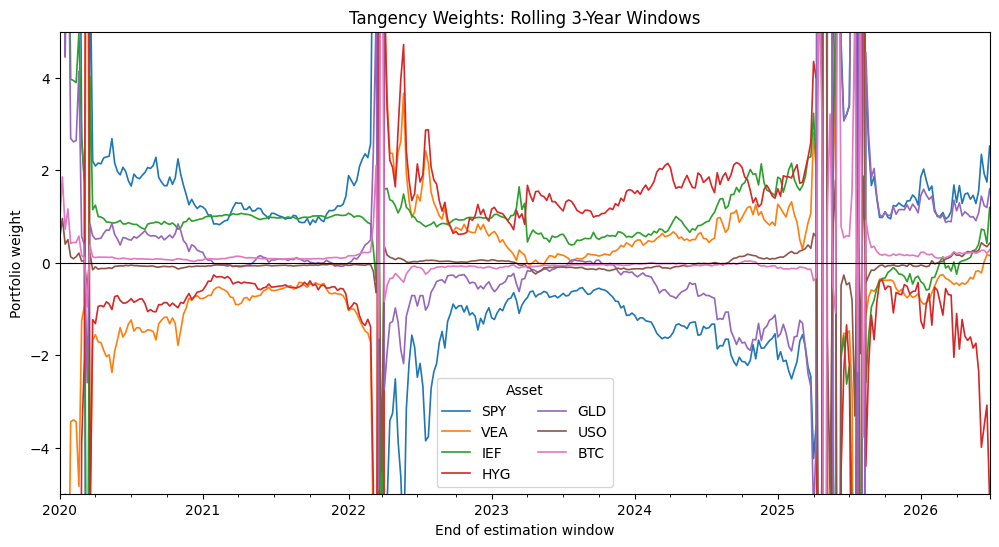

In [ ]:
# 6.1: rolling 3-year (156-week) tangency weights for all 7 assets
import matplotlib.pyplot as plt

window = 156
rolling_weights = []
rolling_dates = []

for end in range(window, len(rets) + 1):
    sample = rets.iloc[end-window:end]
    w = tangency(sample)
    rolling_weights.append(w)
    rolling_dates.append(sample.index[-1])

rolling_weights = pd.DataFrame(rolling_weights, index=rolling_dates)
rolling_weights.index.name = "window end"

print("Number of rolling windows:", len(rolling_weights))
print("Largest absolute weight:", round(rolling_weights.abs().to_numpy().max(), 2))
display(rolling_weights.head().round(3))

ax = rolling_weights.plot(figsize=(12, 6), linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Tangency Weights: Rolling 3-Year Windows")
ax.set_xlabel("End of estimation window")
ax.set_ylabel("Portfolio weight")
ax.set_ylim(-5, 5)
ax.legend(title="Asset", ncol=2)
plt.show()

**6.1 Interpretation.** We can conclude that the rolling tangency weights are extremely unstable. Consecutive estimation windows are currently differing only by only one week, yet the optimizer makes very large changes in long and short positions. Across the 339 rolling windows, the largest absolute estimated weight is about **139.19**, or roughly **13,919%** of portfolio capital. The graph is clipped at -500% and +500% so the main variation remains visible. This shows that the unconstrained tangency portfolio used is highly sensitive to estimation error.

### 6.2 Subsample comparison

Estimate the same seven-asset tangency portfolio separately on 2017–2019 and 2020–2021.

In [ ]:
# 6.2: tangency weights in two different estimation samples
sample_17_19 = rets.loc["2017":"2019"]
sample_20_21 = rets.loc["2020":"2021"]

w_17_19 = tangency(sample_17_19)
w_20_21 = tangency(sample_20_21)

comparison_62 = pd.DataFrame({
    "2017-2019": w_17_19,
    "2020-2021": w_20_21
})

comparison_pct_62 = 100 * comparison_62
display(comparison_pct_62.round(1).style.format("{:.1f}%"))

# Gross exposure helps show how leveraged the unconstrained portfolios are.
gross_62 = comparison_62.abs().sum().rename("gross exposure")
display((100 * gross_62).round(1).to_frame().style.format("{:.1f}%"))

,2017-2019,2020-2021
SPY,5024.1%,170.4%
VEA,-1691.8%,-108.9%
IEF,1831.3%,108.7%
HYG,-7342.9%,-72.8%
GLD,1861.6%,-6.6%
USO,153.0%,-7.0%
BTC,264.7%,16.1%


,gross exposure
2017-2019,18169.5%
2020-2021,490.5%


**6.2 Interpretation.** The two subsamples produce completely different allocations even though the assets and optimization formula are unchanged. Using 2017–2019, the optimizer assigns approximately **5,024% to SPY**, **-7,343% to HYG**, **1,831% to IEF**, and **1,862% to GLD**, producing gross exposure above **18,000%**. Using 2020–2021, the positions are much smaller: SPY is about **170%**, HYG **-73%**, IEF **109%**, and BTC **16%**, with gross exposure around **491%**. Some assets also change sign so the difference comes entirely from changing the sample used to estimate the inputs, which shows how sensitive the unconstrained tangency solution is.

### 6.3 Why is mean-variance optimization fragile?

**The estimated means are generally the bigger problem.** Expected returns are very noisy and difficult to estimate precisely from a short historical sample. Variances and covariances also contain estimation error, but they are usually more stable than sample means. In the tangency formula, $w^{tan} \propto \Sigma^{-1}\mu$, small errors in the estimated mean vector can be magnified by the inverse covariance matrix into very large long-short positions.

The results in 6.1 and 6.2 show this clearly: changing the sample period slightly can produce very different “optimal” portfolios and extreme long or short positions. This is why investors often put limits on portfolio weights, reduce the impact of noisy estimates, or use simpler strategies like equal weighting. These methods may be less mathematically optimal.